In [60]:
import pathlib

benchmark_tree = pathlib.Path() / '..' / 'benchmark' / 'aig' / 'mcnc' / 'x2.json'
benchmark_entropy = pathlib.Path() / '..' / 'benchmark' / 'entropy' / 'mcnc' / 'x2.json'

In [61]:
import landauer.entropy as entropy
import landauer.parse as parse

with open(benchmark_tree) as f:
    aig = parse.deserialize(f.read())

with open(benchmark_entropy) as f:
    entropy_data = entropy.deserialize(f.read())

==== Melhor Solução ====
Energia: 69.43608768437896(0.5255445945379659%)
Delay: 75(-6.5%)


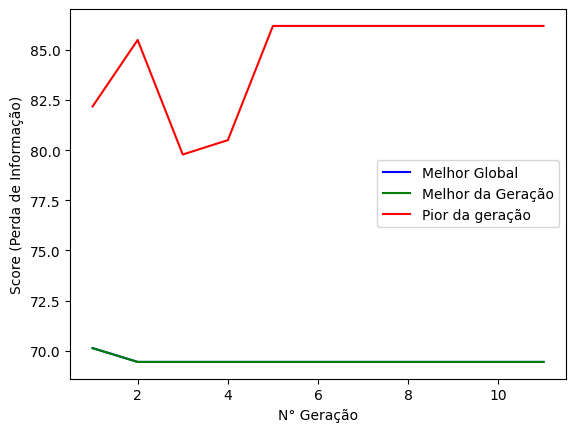

In [3]:
import landauer.summary as summary
import landauer.algorithms.genetic as genetic

param_map = {
    'name': 'Parametrização Básica',
    'n_generations': 10,
    'n_initial_individuals': 30,
    'reproduction_rate': 1,
    'mutation_rate': 0.2,
    'mutation_intensity': 0.1,
    'elitism_rate': 0.1
}


results = genetic.genetic(aig, entropy_data, param_map, show_debug_messages=False, timeout=300, plot_results=True)
solutions = list(map(lambda x: x.forwarding, results['solutions']))

samples = list()
for forwarding in solutions:
    details = summary.summary(forwarding, entropy_data)
    samples.append((details['entropy_losses'], details['depth']))

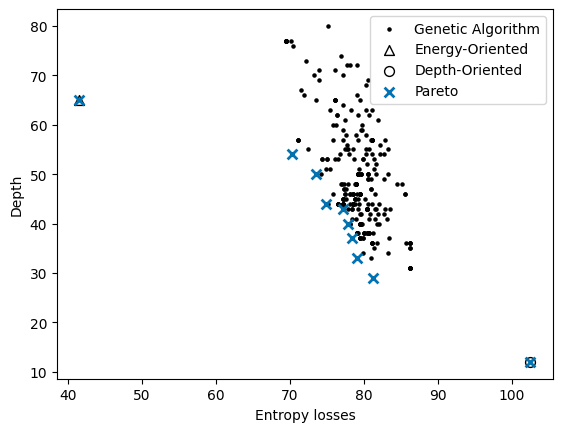

In [4]:
import landauer.plot as plot
import matplotlib.pyplot as plt

p = plot.Plot()
p.plot_samples(samples, 'Genetic Algorithm', legend=False, size=5, color='black')
p.plot_naive(aig, entropy_data)
p.plot_pareto(samples)
plt.savefig('output/pareto/ctrl.png')

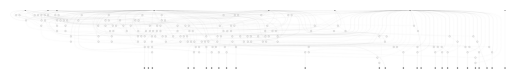

In [5]:
import landauer.graph as graph
import matplotlib.pyplot as plt

graph.save(graph.paper(aig), 'output/netlists/ctrl.png')

MovieWriter ffmpeg unavailable; using Pillow instead.


KeyboardInterrupt: 

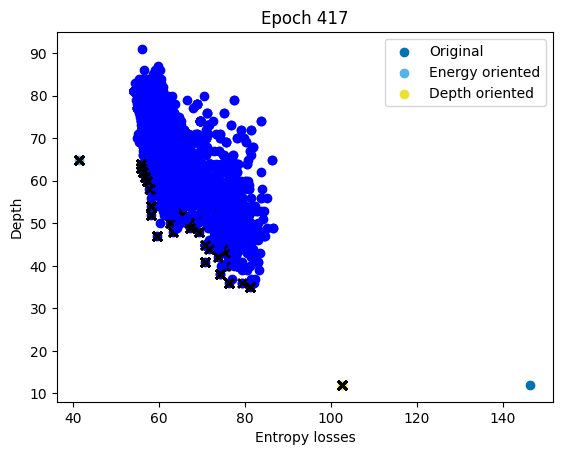

In [5]:
samples_by_generation = list()

for solutions in results['evolutionary_results']['solutions']:
    forwardings = list(map(lambda x: x.forwarding, solutions))
    samples = list()
    for forwarding in forwardings:
        details = summary.summary(forwarding, entropy_data)
        samples.append((details['entropy_losses'], details['depth']))

    samples_by_generation.append(set(samples))

p = plot.Plot()
p.plot_original(aig, entropy_data)
p.plot_naive(aig, entropy_data)
p.plot_pareto_evolution(samples_by_generation, 'Genético')